<p align="left">
  <img src="../escudo_uach.png" alt="Escudo UACh" width="100"/>
</p>

# Clasificador de Música por Género
#### Segundo Hito de Entrega: Extracción de Características acusticas y Preprocesamiento de datos
Integrantes: Martin Arrigo

## Objetivo General
**"En esta etapa del proyecto, se ejecuta la metodología definida en el Hito 1. Se cargarán los audios, se extraerán las características acústicas con librosa y se procedera a entrenar el modelo KNN y revisar sus resultados."**



## Objetivos Especificos

1. Una justificacion teorica las caracteristicas a extraer, y posteriomente comenzar con el proceso de carga de archvos del data set GTZAN 

2. Extraccion de la caracteristicas acusticas y guardo en un archivo df_features.csv

3.  Leer el archivo para ver Revisar los datos 

4.  Verificar los datos 

5. Construccion de graficos para visualizar la diferencia de tempo de cada genero musical

6. Dividir y Preprocesar el Conjunto de Datos

7. Visualizar los resultados del modelo usado




## Explicación de las características usadas para el entrenamiento del modelo

El objetivo del preprocesamiento es convertir la señal de audio digital en un vector numérico compacto, un proceso llamado extracción de características. Este vector debe representar eficientemente la información que define a un género musical.

En el paper de referencia, "Musical Genre Classification of Audio Signals", se establece que los géneros musicales son categorías creadas por humanos, las cuales se distinguen por las siguientes características: la **instrumentación (timbre)**, la **estructura rítmica** y el **contenido armónico**.

En este trabajo la función de `extraer_caracteristicas` funciona a partir de los tres pilares fundamentales:



### 1. Características de Textura Tímbrica

El timbre es la "calidad" del sonido, que nos permite diferenciar los diferentes instrumentos.

* **MFCCs:** La idea los MFCCs (Coeficientes Cepstrales en las Frecuencias de Mel) como la característica más importante para identificar el "timbre" o la "textura" de un sonido, es una forma inteligente de resumir cómo suena algo, imitando cómo funciona el oído humano. Nuestro oído es muy bueno para notar pequeñas diferencias en sonidos graves, pero no tanto en sonidos agudos. Los MFCCs hacen lo mismo: prestan más atención a las frecuencias bajas y resumen toda la forma del sonido en unos pocos números. 

* **Contraste Espectral:** Lo que hace es mirar el sonido y medir la diferencia entre las partes más ruidosas (picos) y las más silenciosas (valles).

* **Tasa de Cruce por Cero:** Es una medida simple de cuán "ruidosa" es la señal.
    * Una señal "limpia" (como una flauta) tiene pocos cruces por cero.
    * Una señal "ruidosa" (como una guitarra distorsionada o estática) tiene muchísimos cruces.


### 2. Características de Estructura Rítmica

* **Tempo:** Corresponde al pulso principal de la canción (el pico más dominante del Histograma de Ritmo). Es crucial para diferenciar géneros definidos por su velocidad.


### 3. Características de Contenido Armónico

El contenido armónico se refiere a las notas, acordes y relaciones tonales que componen una pieza musical.

* **Cromagrama:** Un cromagrama "pliega" todo el espectro de frecuencias de la canción en solo 12 contenedores . Cada contenedor representa una de las 12 notas de la escala musical (Do, Re, Mi, Fa, etc.).

> **Obs:** Este proceso es fundamental porque ignora deliberadamente la octava (es decir, no le importa si es un Do agudo o un Do grave) y se concentra puramente en qué notas se están tocando.






##### Paso 1: Se cargarán los datos del dataset GTZAN utilizando las funciones definidas en procesamiento.py. Luego, se realizará un análisis exploratorio (EDA) de las características extraídas


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Ruta a los datos
DATASET_PATH = '../Data'

#### Paso 2: Se procede a llamar a la función extraer_caracteristicas, la cual itera sobre todas las carpetas de género, carga cada archivo .wav con librosa, extrae el conjunto de características (MFCCs, Chroma, Contraste Espectral, etc.) y devuelve un DataFrame 



In [2]:
# Ejecutamos la extracción
from FP import extraer_caracteristicas

print(DATASET_PATH)

df_features = extraer_caracteristicas(DATASET_PATH)
df_features.to_csv('features_extraidas.csv', index=False)

../Data
Iniciando extracción...
Fin de la extraccion ...


#### Paso 3: Se lee el archivo.csv generado apartir de los datos extraidos anteriormente

In [3]:
# Cargar datos pre-extraídos para agilizar el análisis
df_features = pd.read_csv('features_extraidas.csv')
print(df_features.shape)

df_features.head()



(1000, 42)


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,spec_contrast_0,spec_contrast_1,spec_contrast_2,spec_contrast_3,spec_contrast_4,spec_contrast_5,spec_contrast_6,zcr,tempo,genre
0,-113.619385,121.55302,-19.151056,42.345768,-6.371168,18.613033,-13.692060,15.339378,-12.283618,10.973775,...,15.987603,15.102478,18.458409,18.363125,18.918739,17.190236,39.667577,0.083066,123.046875,blues
1,-207.581510,123.99715,8.939115,35.870758,2.919970,21.518787,-8.555368,23.355938,-10.101037,11.906445,...,15.984915,17.056233,19.129324,19.187871,18.324039,17.504480,37.518985,0.056044,67.999589,blues
2,-90.776340,140.44861,-29.100560,31.687340,-13.975971,25.741686,-13.644712,11.623112,-11.775920,9.700466,...,26.332256,14.191933,17.706644,19.417250,20.344435,18.314965,39.035077,0.076301,161.499023,blues
3,-199.462000,150.09473,5.649167,26.870144,1.755441,14.236880,-4.828873,9.297849,-0.753142,8.147393,...,29.797804,14.765637,17.239784,18.636217,18.490758,16.790485,34.278016,0.033309,63.024009,blues
4,-160.291850,126.19576,-35.602500,22.151169,-32.487640,10.862022,-23.357162,0.500523,-11.804770,1.203878,...,17.057413,15.693513,19.125559,20.526383,20.785517,19.713927,37.338804,0.101500,135.999178,blues


#### Paso 4: Verificar datos

In [4]:
print(df_features['genre'].value_counts())
print(df_features.isnull().sum().any())

genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64
False


#### Paso 5: Grafico de los datos,este gráfico nos muestra las velocidades (Tempo o BPM) de todas las canciones, agrupadas por género una forma simple de interpretar el grafico es leer  el diagrama de bigotes (caja azul) es el rango de velocidad "normal" para el 50% (la mitad) de las canciones de ese género.


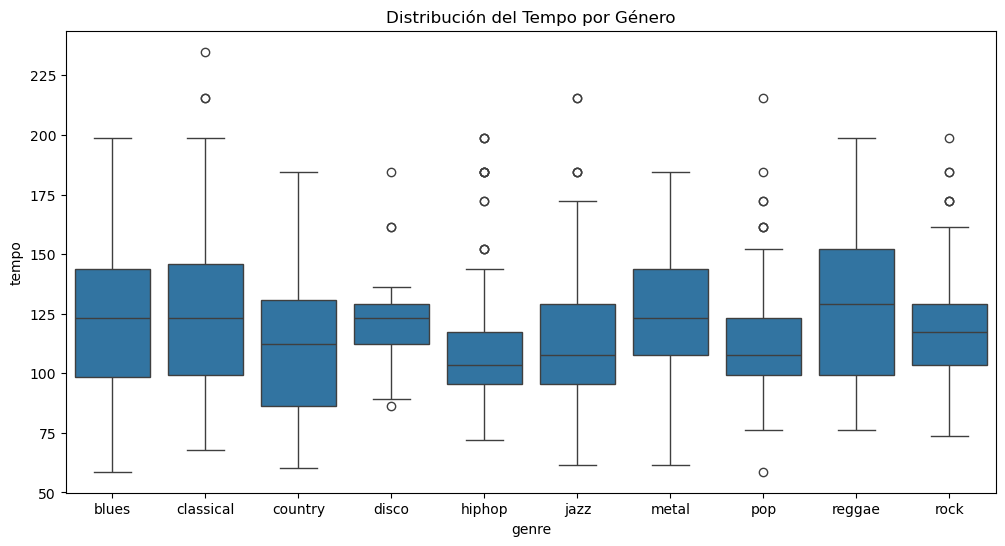

In [5]:
# Visualización (ej. Tempo)
plt.figure(figsize=(12, 6))
sns.boxplot(data=round(df_features,1), x='genre', y='tempo')
plt.title('Distribución del Tempo por Género')
plt.show()

#### Paso 6: Para preparar nuestros datos para el modelo de Machine Learning, necesitamos realizar los siguietes pasos:

1. División (Split): Separar nuestro dataframe completo (df_features) en dos conjuntos: uno para entrenar el modelo (datos de entrenamiento) y otro para probar qué tan bien aprendió (datos de prueba).

2. Preprocesamiento (Scaling/Encoding) Aplicar las transformaciones necesarias a esos datos para que el modelo pueda entenderlos (escalar los números y codificar las etiquetas de texto).

La logica mencionada esta programada en el archivo FP en donde llamamanos a la funcion `preprocesar_datos`

In [16]:
from FP import preprocesar_datos
X_train, X_test, y_train, y_test, scaler, encoder = preprocesar_datos(df_features)

print(f"Datos de entrenamiento (X_train): {X_train.shape}")
print(f"Datos de prueba (X_test): {X_test.shape}")


print(f"Datos de entrenamiento (y_train): {y_train.shape}")
print(f"Datos de prueba (X_test): {y_test.shape}")




Datos de entrenamiento (X_train): (750, 41)
Datos de prueba (X_test): (250, 41)
Datos de entrenamiento (y_train): (750,)
Datos de prueba (X_test): (250,)


#### Paso 7: Entrenar el modelo se prueba con dos modelos KNN y random forest 

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear el modelo KNN
modelo = KNeighborsClassifier(n_neighbors=5) 

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Evaluar el modelo
y_pred = modelo.predict(X_test)

print("📊 Resultados del modelo KNN:")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("")
print("Reporte de clasificación:\t")
print("")
print(classification_report(y_test, y_pred))


📊 Resultados del modelo KNN:

Matriz de confusión:
[[18  0  2  4  0  3  0  0  1  1]
 [ 0 16  0  0  0  1  0  0  0  0]
 [ 0  3 18  3  0  2  0  2  0  3]
 [ 1  0  3 10  4  2  2  5  0  0]
 [ 0  0  2  2 11  0  0  2  0  1]
 [ 1  4  1  0  2 21  0  0  0  0]
 [ 0  0  0  0  4  0 23  0  0  1]
 [ 0  1  1  0  0  0  0 13  1  0]
 [ 2  0  3  0  7  2  0  2 10  1]
 [ 1  1  5  8  4  2  0  3  1  3]]

Reporte de clasificación:	

              precision    recall  f1-score   support

           0       0.78      0.62      0.69        29
           1       0.64      0.94      0.76        17
           2       0.51      0.58      0.55        31
           3       0.37      0.37      0.37        27
           4       0.34      0.61      0.44        18
           5       0.64      0.72      0.68        29
           6       0.92      0.82      0.87        28
           7       0.48      0.81      0.60        16
           8       0.77      0.37      0.50        27
           9       0.30      0.11      0.16     

📊 RESUMEN ESTADÍSTICO DEL CLASIFICADOR KNN
-------------------------------------------------
🔹 Precisión global (accuracy): 0.5720
🔹 Precisión ponderada (precision): 0.5872
🔹 Recall ponderado (recall): 0.5720
🔹 F1-score ponderado: 0.5576
-------------------------------------------------

📄 Reporte de clasificación por género:
              precision    recall  f1-score   support

           0       0.78      0.62      0.69        29
           1       0.64      0.94      0.76        17
           2       0.51      0.58      0.55        31
           3       0.37      0.37      0.37        27
           4       0.34      0.61      0.44        18
           5       0.64      0.72      0.68        29
           6       0.92      0.82      0.87        28
           7       0.48      0.81      0.60        16
           8       0.77      0.37      0.50        27
           9       0.30      0.11      0.16        28

    accuracy                           0.57       250
   macro avg       0.5

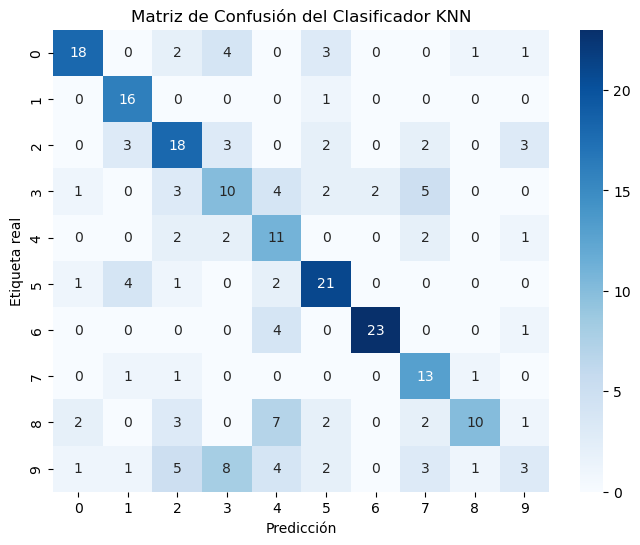

In [ ]:
import sklearn.metrics  as Me  #Me son las metricas estadisticas para revisar la estabilidad del modelo 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Predicción ---
y_pred = modelo.predict(X_test)

# --- Métricas generales ---
accuracy = Me.accuracy_score(y_test, y_pred)
precision = Me.precision_score(y_test, y_pred, average='weighted')
recall = Me.recall_score(y_test, y_pred, average='weighted')
f1 = Me.f1_score(y_test, y_pred, average='weighted')

print("📊 RESUMEN ESTADÍSTICO DEL CLASIFICADOR KNN")
print("-------------------------------------------------")
print(f"🔹 Precisión global (accuracy): {accuracy:.4f}")
print(f"🔹 Precisión ponderada (precision): {precision:.4f}")
print(f"🔹 Recall ponderado (recall): {recall:.4f}")
print(f"🔹 F1-score ponderado: {f1:.4f}")
print("-------------------------------------------------\n")

# --- Reporte detallado por clase ---
print("📄 Reporte de clasificación por género:")
print(classification_report(y_test, y_pred))

# --- Matriz de confusión (gráfico) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión del Clasificador KNN")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.show()


## Referencias Bibliográficas:

1. Lachmish, M. (2021). *MusicGenreClassification* [Repositorio de software]. GitHub. https://github.com/mlachmish/MusicGenreClassification
2. Zapata, J. R. (s.f.). Extracción de características de audio. https://joserzapata.github.io/courses/mineria-audio/extraccion_caracteristicas/
3. Tzanetakis, G., & Cook, P. (2002). Musical genre classification of audio signals. *IEEE Transactions on Speech and Audio Processing*, *10*(5), 293–302. https://doi.org/10.1109/TSA.2002.800560
4. Xu, C., Maddage, N. C., Shao, X., Cao, F., & Tian, Q. (2003). Musical genre classification using support vector machines. En Proceedings of the 2003 IEEE International Conference on Multimedia and Expo (ICME '03) (Vol. 1, pp. I-101-I-104). IEEE. https://doi.org/10.1109/ICME.2003.1221291
